# **Entrenamiento de la CNN**

En este notebook implementamos y entrenamos la red neuronal convolucional
que clasifica los latidos cardíacos como normales o anormales.

Partimos de los datos preprocesados y entrenamos una CNN 1D
diseñada específicamente para series temporales de ECG.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.metrics import f1_score

# Semilla para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cpu


In [ ]:
# Montar Drive si usamos Colab (comentar si ejecutamos en local)
# from google.colab import drive
# drive.mount('/content/drive')
# os.chdir("/content/drive/MyDrive/Colab Notebooks/ECGAssistant_Sprint1")

import os
print("Directorio:", os.getcwd())

Mounted at /content/drive
Directorio: /content/drive/.shortcut-targets-by-id/1acOp95JDTEWtgyHkn2BDLpHG-oeo8sXh/ECGAssistant_Sprint1


In [4]:
# Cargamos los datos preprocesados
X_train = np.load("X_train.npy")
X_val   = np.load("X_val.npy")
X_test  = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_val   = np.load("y_val.npy")
y_test  = np.load("y_test.npy")

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (51615, 288)
Val:   (7374, 288)
Test:  (14748, 288)


## 1. Preparación de tensores

La CNN espera los datos en formato (batch, canales, longitud).
Añadimos una dimensión de canal con unsqueeze → (N, 1, 288).

In [5]:
# Convertimos a tensores y añadimos dimensión de canal
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)

X_val_t   = torch.tensor(X_val,   dtype=torch.float32).unsqueeze(1).to(device)
y_val_t   = torch.tensor(y_val,   dtype=torch.long).to(device)

X_test_t  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.long).to(device)

# DataLoaders con batch de 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=64)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=64)

print("Shape tensor train:", X_train_t.shape)

Shape tensor train: torch.Size([51615, 1, 288])


## 2. Arquitectura de la CNN

Usamos una CNN 1D con dos bloques convolucionales seguidos de capas densas.

Elegimos este tipo de red porque funciona bien con series temporales: los filtros
aprenden patrones morfológicos del latido (el complejo QRS, la onda P...) sin
que tengamos que definirlos manualmente.

Cada bloque tiene: convolución → batch normalization → ReLU → MaxPooling.

El BatchNorm estabiliza el entrenamiento y el Dropout en la parte densa
evita overfitting.
```
Input: (batch, 1, 288)
│
├── Conv1d(1→16, kernel=5) → BatchNorm → ReLU → MaxPool → (batch, 16, 144)
├── Conv1d(16→32, kernel=5) → BatchNorm → ReLU → MaxPool → (batch, 32, 72)
│
├── Flatten → (batch, 2304)
├── Dropout(0.3)
├── Linear(2304→64) + ReLU
└── Linear(64→2) ← Normal / Anormal
```

In [6]:
class ECG_CNN(nn.Module):

    def __init__(self):
        super(ECG_CNN, self).__init__()

        # Bloque 1: (batch, 1, 288) → (batch, 16, 144)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(16)

        # Bloque 2: (batch, 16, 144) → (batch, 32, 72)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(32)

        # MaxPool reduce la dimensión temporal a la mitad en cada bloque
        self.pool    = nn.MaxPool1d(kernel_size=2)
        self.dropout = nn.Dropout(0.3)

        # Clasificador: 32 filtros × 72 muestras = 2304 neuronas
        self.fc1 = nn.Linear(32 * 72, 64)
        self.fc2 = nn.Linear(64, 2)  # 2 clases: normal y anormal

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


model = ECG_CNN().to(device)

# Verificamos shapes con un batch de ejemplo
dummy  = torch.randn(1, 1, 288).to(device)
output = model(dummy)
print("Output shape:", output.shape)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {total_params:,}")

Output shape: torch.Size([1, 2])
Parámetros entrenables: 150,434


## 3. Función de pérdida y optimizador

El dataset tiene un desbalance ~70/30. Para que el modelo no aprenda a
predecir siempre normal, usamos pesos de clase inversamente proporcionales
a su frecuencia. Así cada error en la clase anormal tiene más peso en
el gradiente.

In [7]:
# Pesos inversamente proporcionales a la frecuencia de cada clase
class_counts  = np.bincount(y_train)
class_weights = torch.tensor(
    [1.0 / class_counts[0], 1.0 / class_counts[1]],
    dtype=torch.float32
).to(device)

print(f"Normal:  {class_counts[0]:,} muestras → peso {class_weights[0]:.6f}")
print(f"Anormal: {class_counts[1]:,} muestras → peso {class_weights[1]:.6f}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer  = optim.Adam(model.parameters(), lr=0.001)

Normal:  36,569 muestras → peso 0.000027
Anormal: 15,046 muestras → peso 0.000066


## 4. Entrenamiento

Entrenamos 35 épocas monitorizando el F1 sobre validación en cada época.
Usamos F1 en lugar de accuracy porque con desbalance la accuracy puede
ser engañosa.

In [8]:
def train_model(model, train_loader, val_loader, epochs=35):

    history = {"train_loss": [], "val_f1": []}

    for epoch in range(epochs):

        # Fase de entrenamiento
        model.train()
        train_loss = 0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Fase de validación
        model.eval()
        val_preds, val_true = [], []

        with torch.no_grad():
            for xb, yb in val_loader:
                preds = torch.argmax(model(xb), dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_true.extend(yb.cpu().numpy())

        avg_loss = train_loss / len(train_loader)
        f1       = f1_score(val_true, val_preds)

        history["train_loss"].append(avg_loss)
        history["val_f1"].append(f1)

        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {avg_loss:.4f} | Val F1: {f1:.4f}")

    return history


history = train_model(model, train_loader, val_loader, epochs=35)

Epoch 01/35 | Loss: 0.1364 | Val F1: 0.9638
Epoch 02/35 | Loss: 0.0823 | Val F1: 0.9710
Epoch 03/35 | Loss: 0.0660 | Val F1: 0.9747
Epoch 04/35 | Loss: 0.0543 | Val F1: 0.9674
Epoch 05/35 | Loss: 0.0472 | Val F1: 0.9518
Epoch 06/35 | Loss: 0.0426 | Val F1: 0.9818
Epoch 07/35 | Loss: 0.0373 | Val F1: 0.9804
Epoch 08/35 | Loss: 0.0371 | Val F1: 0.9838
Epoch 09/35 | Loss: 0.0335 | Val F1: 0.9844
Epoch 10/35 | Loss: 0.0339 | Val F1: 0.9818
Epoch 11/35 | Loss: 0.0295 | Val F1: 0.9841
Epoch 12/35 | Loss: 0.0273 | Val F1: 0.9841
Epoch 13/35 | Loss: 0.0252 | Val F1: 0.9849
Epoch 14/35 | Loss: 0.0260 | Val F1: 0.9837
Epoch 15/35 | Loss: 0.0233 | Val F1: 0.9851
Epoch 16/35 | Loss: 0.0218 | Val F1: 0.9849
Epoch 17/35 | Loss: 0.0221 | Val F1: 0.9833
Epoch 18/35 | Loss: 0.0208 | Val F1: 0.9799
Epoch 19/35 | Loss: 0.0210 | Val F1: 0.9867
Epoch 20/35 | Loss: 0.0189 | Val F1: 0.9844
Epoch 21/35 | Loss: 0.0166 | Val F1: 0.9824
Epoch 22/35 | Loss: 0.0175 | Val F1: 0.9856
Epoch 23/35 | Loss: 0.0178 | Val

## 5. Curvas de entrenamiento

Visualizamos la evolución del loss y del F1 durante el entrenamiento
para comprobar que el modelo ha convergido correctamente y que no hay
overfitting.

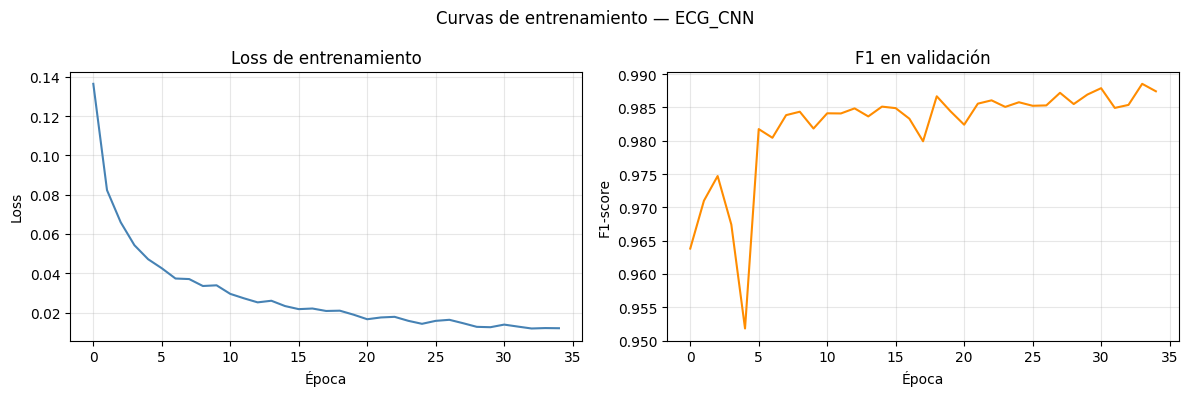

Mejor Val F1: 0.9885 (época 34)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], color="steelblue")
axes[0].set_title("Loss de entrenamiento")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["val_f1"], color="darkorange")
axes[1].set_title("F1 en validación")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("F1-score")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Curvas de entrenamiento — ECG_CNN", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Mejor Val F1: {max(history['val_f1']):.4f} (época {np.argmax(history['val_f1'])+1})")

## Reflexión del entrenamiento

El modelo llega a la época 35 con un loss de 0.0120, lo que indica que
ha aprendido bien los patrones del ECG. El F1 en validación de 0.9874
es un resultado muy sólido para una clasificación binaria con datos médicos.
La bajada progresiva del loss sin que el F1 de validación se desplome
indica que no hay overfitting significativo.

In [10]:
# Guardamos el modelo entrenado
torch.save(model.state_dict(), "ecg_cnn.pt")
print("Modelo guardado en ecg_cnn.pt")

Modelo guardado en ecg_cnn.pt
